# MAgent2 Torch Robust MF-DSRQ Training

Train the Torch-native robust-action mean-field SRQ variant on `battle_v4` for four fixed robust epsilon values. Each epsilon gets its own run directory, reward/win plot, and final kill-rule win-rate summary.

In [6]:
from pathlib import Path
import sys


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.notebook_utils import (
    mfdsrq_epsilon_config,
    notebook_mfdsrq_config,
    plot_mfdsrq_training_curves,
    print_mfdsrq_training_win_rates,
    train_mfdsrq_from_notebook,
)

NUM_EPISODES = 2000
MAX_CYCLES = 400
NUM_ENVS = 16
MAP_SIZE = 40
SEED = 42
ALGORITHM = "mf_srq_torch"
ROBUST_DISTANCE = "tv"
ROBUST_LP_FALLBACK = "greedy_tv"
ROBUST_POLICY_TEMPERATURE = 0.1
SMOOTHING_WINDOW = 20
EPSILONS = [0.01, 0.1, 0.5, 1.0]

OUTPUT_ROOT = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs" / "mf_srq_torch_epsilon_training"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

BASE_CFG = notebook_mfdsrq_config(
    target_episodes=NUM_EPISODES,
    num_envs=NUM_ENVS,
    map_size=MAP_SIZE,
    max_cycles=MAX_CYCLES,
    output_dir=OUTPUT_ROOT,
    seed=SEED,
    extra_overrides={
        "algorithm": ALGORITHM,
        "robust_distance": ROBUST_DISTANCE,
        "robust_lp_fallback": ROBUST_LP_FALLBACK,
        "robust_policy_temperature": ROBUST_POLICY_TEMPERATURE,
        "batch_size": 256,
        "max_train_batches_per_update": None,
    },
)

MFDSRQ_TORCH_RESULTS = {}
BASE_CFG


{'algorithm': 'mf_srq_torch',
 'env_name': 'battle_v4',
 'env_backend': 'magent2',
 'map_size': 40,
 'max_cycles': 400,
 'type_prefixes': {'red': 'red_', 'blue': 'blue_'},
 'mean_field_source': 'opponent',
 'epsilon_robust_start': 0.1,
 'epsilon_robust_end': 0.02,
 'epsilon_robust_decay_frac': 1.0,
 'robust_distance': 'tv',
 'robust_lp_fallback': 'greedy_tv',
 'robust_policy_cache_enabled': True,
 'robust_policy_cache_size': 4096,
 'robust_policy_cache_round_digits': 6,
 'epsilon_explore_start': 1.0,
 'epsilon_explore_mid': 0.2,
 'epsilon_explore_mid_fraction': 0.8,
 'epsilon_explore_end': 0.1,
 'gamma': 0.95,
 'lr': 0.0001,
 'batch_size': 256,
 'buffer_capacity': 80000,
 'learning_starts': 5000,
 'train_every': 5,
 'target_tau': 0.005,
 'grad_clip': 10.0,
 'target_episodes': 2000,
 'num_envs': 16,
 'seed': 42,
 'self_play_tau': 0.01,
 'max_train_batches_per_update': None,
 'output_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training

## Robust Epsilon 0.01

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-818.569 mean_opponent_reward=-814.294 loss=0.0221 episodes_per_sec=0.50
[mf_srq_torch] episodes=800/2000 mean_main_reward=-2.884 mean_opponent_reward=-112.033 loss=0.3149 episodes_per_sec=0.44
[mf_srq_torch] episodes=1200/2000 mean_main_reward=266.817 mean_opponent_reward=-2.908 loss=0.7866 episodes_per_sec=0.51
[mf_srq_torch] episodes=1600/2000 mean_main_reward=238.938 mean_opponent_reward=-54.810 loss=0.2972 episodes_per_sec=0.54
[mf_srq_torch] episodes=2000/2000 mean_main_reward=238.395 mean_opponent_reward=-62.568 loss=0.2975 episodes_per_sec=0.58

Training complete. 2000 episodes, 391,206 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42/training_stats.json
Saved training curves 

{'main': 0.885, 'opponent': 0.06}

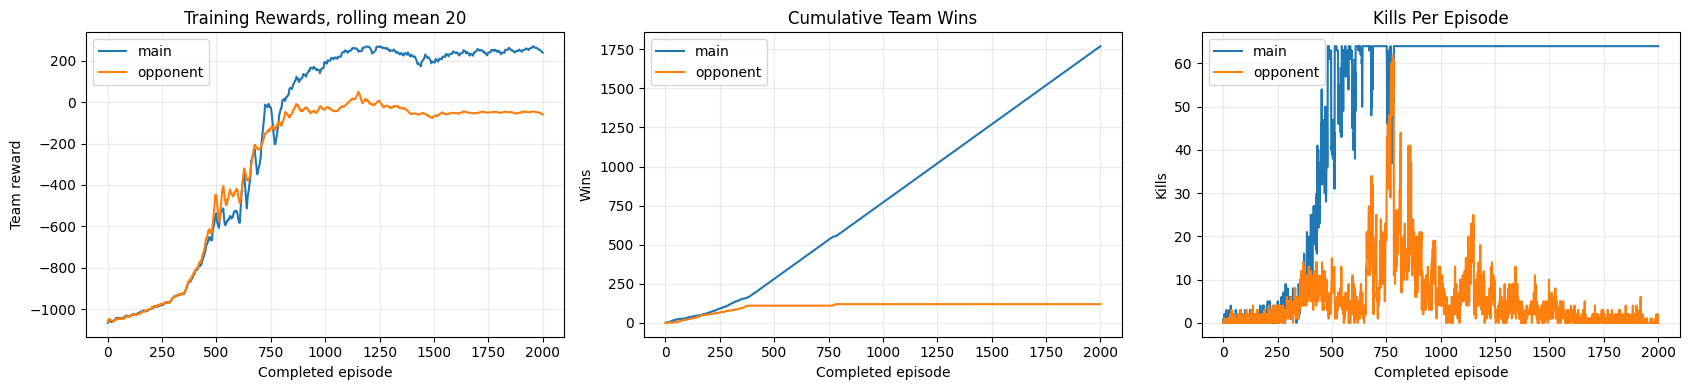

In [2]:
epsilon = 0.01
cfg_eps_0_01 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_01 = train_mfdsrq_from_notebook(cfg_eps_0_01)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_01
plot_mfdsrq_training_curves(result_eps_0_01, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_01)


## Robust Epsilon 0.1

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-879.012 mean_opponent_reward=-880.516 loss=0.0127 episodes_per_sec=0.38
[mf_srq_torch] episodes=800/2000 mean_main_reward=-76.644 mean_opponent_reward=-60.990 loss=0.2053 episodes_per_sec=0.38
[mf_srq_torch] episodes=1200/2000 mean_main_reward=237.489 mean_opponent_reward=3.174 loss=0.4689 episodes_per_sec=0.44
[mf_srq_torch] episodes=1600/2000 mean_main_reward=234.189 mean_opponent_reward=-33.213 loss=0.2952 episodes_per_sec=0.48
[mf_srq_torch] episodes=2000/2000 mean_main_reward=255.631 mean_opponent_reward=-28.660 loss=0.2852 episodes_per_sec=0.51

Training complete. 2000 episodes, 416,152 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42/training_stats.json
Saved training curves to 

{'main': 0.853, 'opponent': 0.0895}

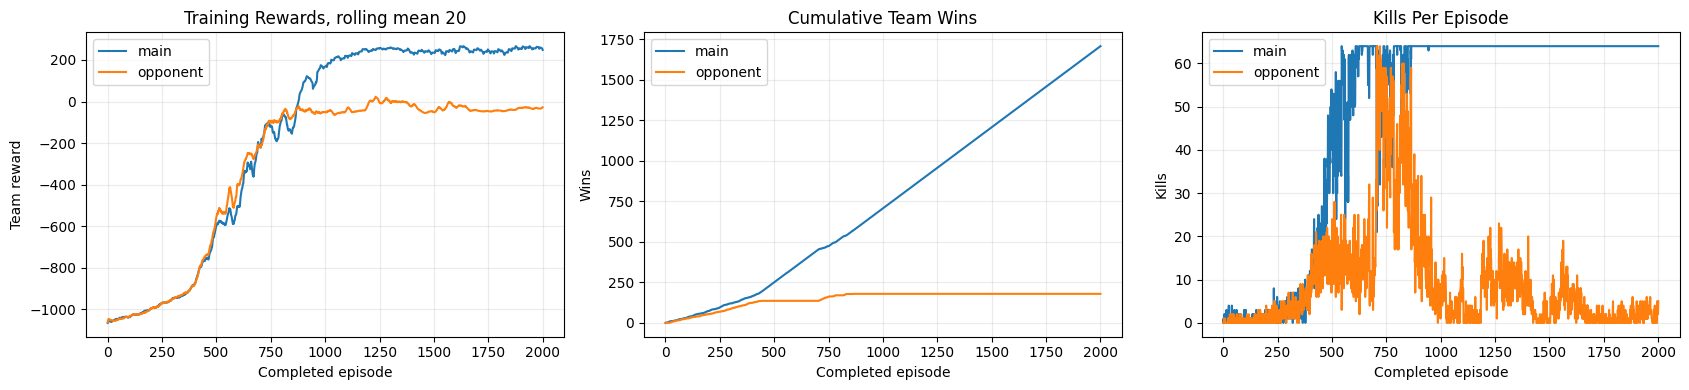

In [3]:
epsilon = 0.1
cfg_eps_0_1 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_1 = train_mfdsrq_from_notebook(cfg_eps_0_1)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_1
plot_mfdsrq_training_curves(result_eps_0_1, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_1)


## Robust Epsilon 0.5

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-940.052 mean_opponent_reward=-917.701 loss=0.0117 episodes_per_sec=0.27
[mf_srq_torch] episodes=800/2000 mean_main_reward=-508.506 mean_opponent_reward=-374.909 loss=0.0276 episodes_per_sec=0.27
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-217.909 mean_opponent_reward=-151.808 loss=0.0337 episodes_per_sec=0.27
[mf_srq_torch] episodes=1600/2000 mean_main_reward=-43.724 mean_opponent_reward=17.794 loss=0.0163 episodes_per_sec=0.28
[mf_srq_torch] episodes=2000/2000 mean_main_reward=218.020 mean_opponent_reward=-31.187 loss=0.2280 episodes_per_sec=0.29

Training complete. 2000 episodes, 689,197 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42/training_stats.json
Saved training curve

{'main': 0.841, 'opponent': 0.0825}

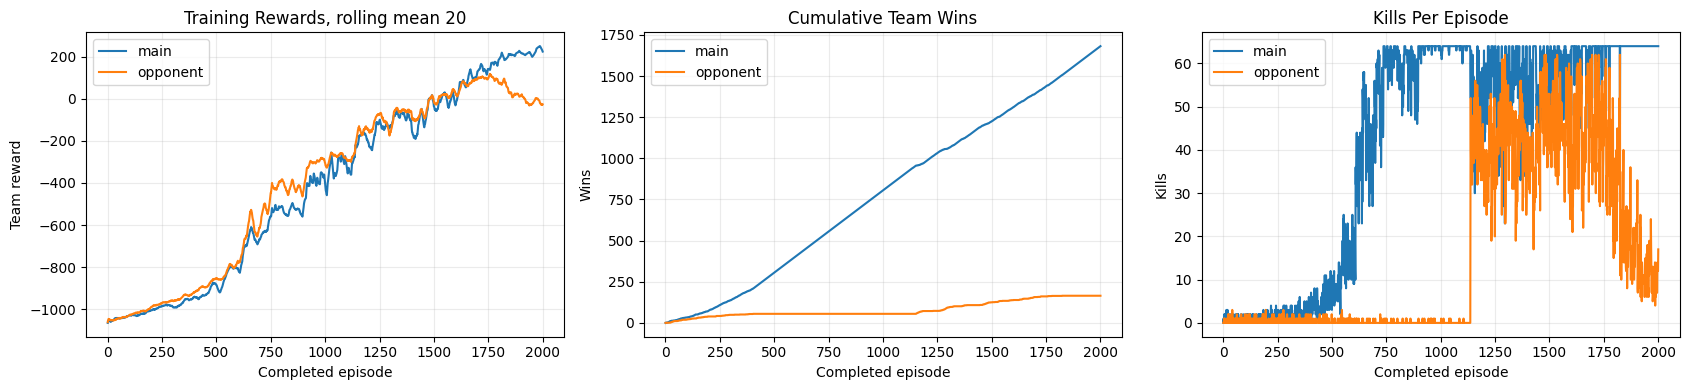

In [4]:
epsilon = 0.5
cfg_eps_0_5 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_5 = train_mfdsrq_from_notebook(cfg_eps_0_5)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_5
plot_mfdsrq_training_curves(result_eps_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_5)

## Robust Epsilon 1.0

In [ ]:
epsilon = 1.0
cfg_eps_1_0 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_1_0 = train_mfdsrq_from_notebook(cfg_eps_1_0)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_1_0
plot_mfdsrq_training_curves(result_eps_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_1_0)


## Decay 0.5 to 0

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-928.244 mean_opponent_reward=-924.485 loss=0.0120 episodes_per_sec=0.29
[mf_srq_torch] episodes=800/2000 mean_main_reward=-527.837 mean_opponent_reward=-479.376 loss=0.0426 episodes_per_sec=0.29
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-210.983 mean_opponent_reward=-63.838 loss=0.0078 episodes_per_sec=0.29
[mf_srq_torch] episodes=1600/2000 mean_main_reward=276.554 mean_opponent_reward=-33.142 loss=0.4566 episodes_per_sec=0.32
[mf_srq_torch] episodes=2000/2000 mean_main_reward=276.885 mean_opponent_reward=-25.913 loss=0.5844 episodes_per_sec=0.35

Training complete. 2000 episodes, 564,666 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42/training_stats.j

{'main': 0.733, 'opponent': 0.1905}

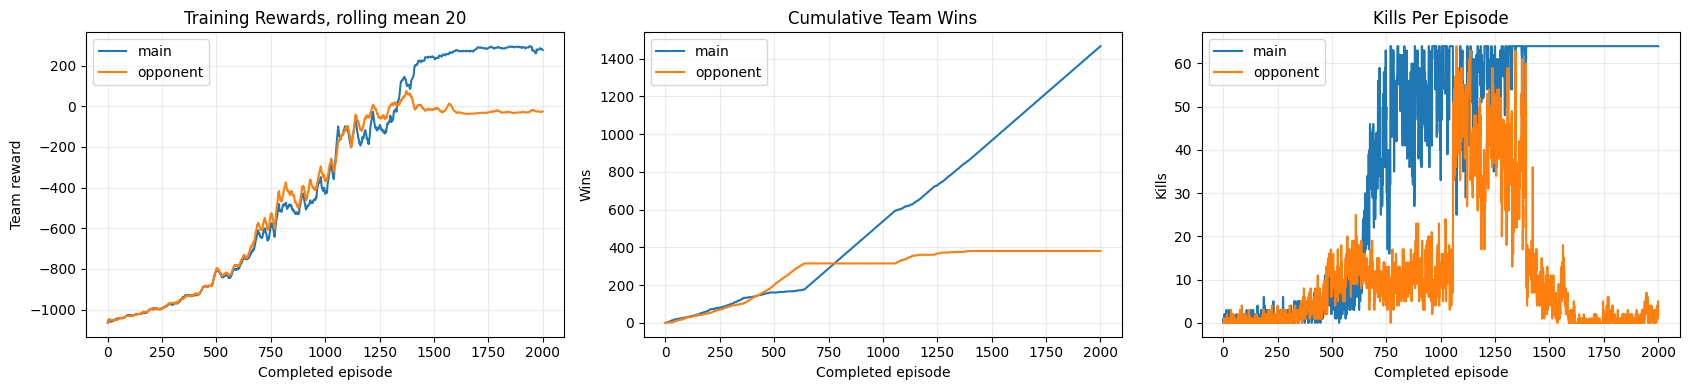

In [7]:
epsilon_start = 0.5
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_5_to_0 = dict(BASE_CFG)
cfg_decay_0_5_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_5_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_5_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_5_to_0
plot_mfdsrq_training_curves(result_decay_0_5_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_5_to_0)

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-972.129 mean_opponent_reward=-945.484 loss=0.0225 episodes_per_sec=0.24
[mf_srq_torch] episodes=800/2000 mean_main_reward=-369.950 mean_opponent_reward=-389.275 loss=0.0316 episodes_per_sec=0.25
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-307.510 mean_opponent_reward=-255.672 loss=0.0237 episodes_per_sec=0.27
[mf_srq_torch] episodes=1600/2000 mean_main_reward=-28.392 mean_opponent_reward=-46.052 loss=0.0478 episodes_per_sec=0.28
[mf_srq_torch] episodes=2000/2000 mean_main_reward=266.673 mean_opponent_reward=-29.625 loss=0.4407 episodes_per_sec=0.31

Training complete. 2000 episodes, 676,731 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42/training_stat

{'main': 0.448, 'opponent': 0.4465}

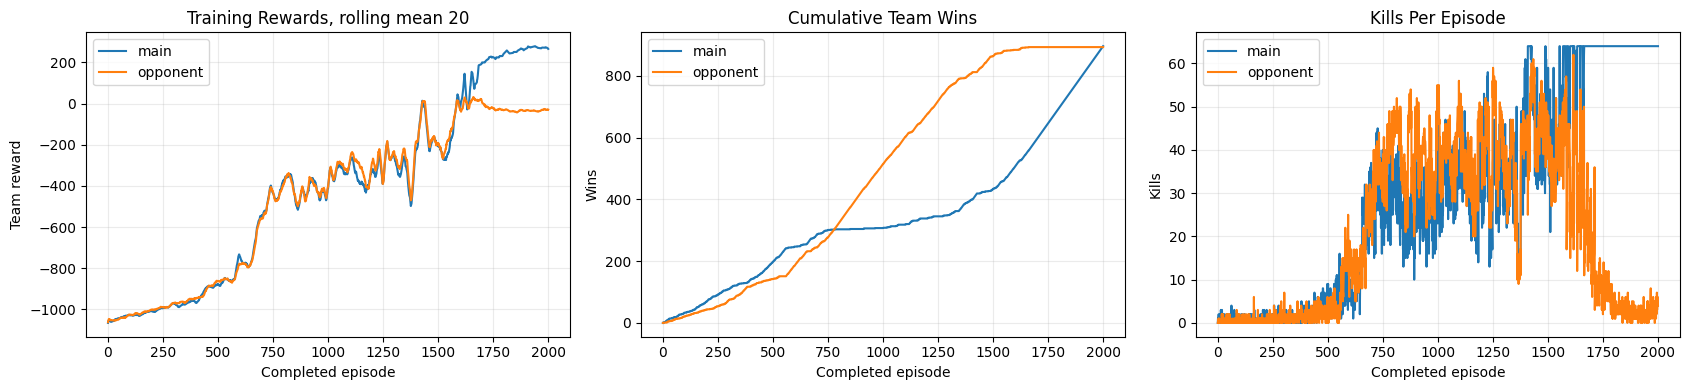

In [8]:
# Robust epsilon schedule: 0.75 -> 0
epsilon_start = 0.75
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_75_to_0 = dict(BASE_CFG)
cfg_decay_0_75_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_75_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_75_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_75_to_0
plot_mfdsrq_training_curves(result_decay_0_75_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_75_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-994.421 mean_opponent_reward=-922.809 loss=0.0721 episodes_per_sec=0.24
[mf_srq_torch] episodes=800/2000 mean_main_reward=-389.681 mean_opponent_reward=-472.703 loss=0.0612 episodes_per_sec=0.24
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-363.245 mean_opponent_reward=-323.938 loss=0.0174 episodes_per_sec=0.25
[mf_srq_torch] episodes=1600/2000 mean_main_reward=-370.939 mean_opponent_reward=-308.770 loss=0.0122 episodes_per_sec=0.27
[mf_srq_torch] episodes=2000/2000 mean_main_reward=159.405 mean_opponent_reward=22.561 loss=0.1589 episodes_per_sec=0.29

Training complete. 2000 episodes, 773,338 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42/training_stats.jso

{'main': 0.2365, 'opponent': 0.681}

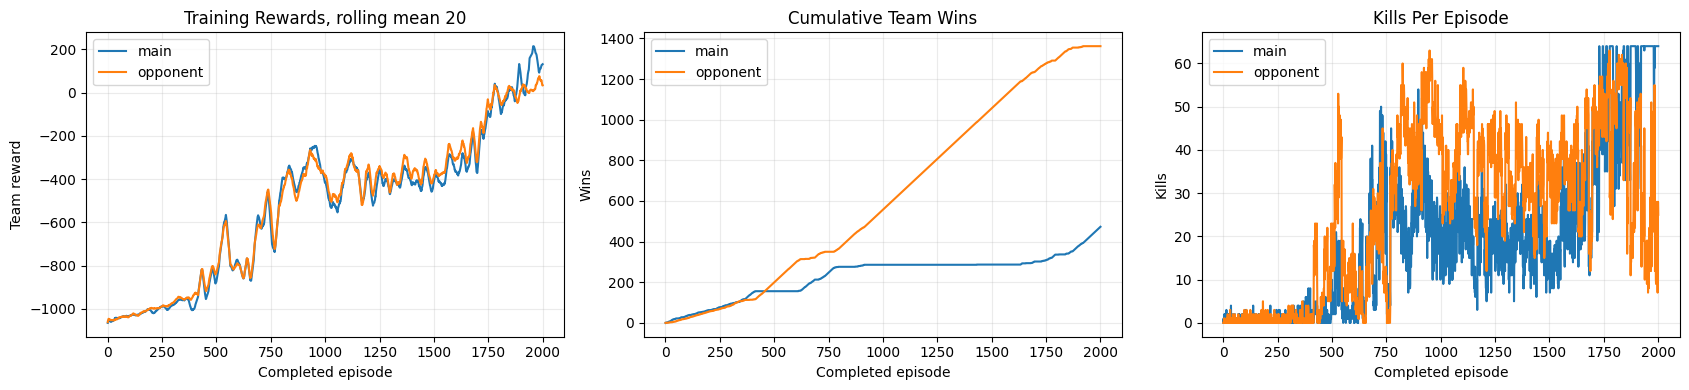

In [9]:
# Robust epsilon schedule: 1 -> 0
epsilon_start = 1.0
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_1_0_to_0 = dict(BASE_CFG)
cfg_decay_1_0_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_1_0_to_0 = train_mfdsrq_from_notebook(cfg_decay_1_0_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_1_0_to_0
plot_mfdsrq_training_curves(result_decay_1_0_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_1_0_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-831.377 mean_opponent_reward=-829.544 loss=0.0141 episodes_per_sec=0.47
[mf_srq_torch] episodes=800/2000 mean_main_reward=-21.022 mean_opponent_reward=-73.310 loss=0.1842 episodes_per_sec=0.42
[mf_srq_torch] episodes=1200/2000 mean_main_reward=189.182 mean_opponent_reward=-56.212 loss=0.2912 episodes_per_sec=0.44
[mf_srq_torch] episodes=1600/2000 mean_main_reward=213.972 mean_opponent_reward=-34.792 loss=0.2754 episodes_per_sec=0.47
[mf_srq_torch] episodes=2000/2000 mean_main_reward=224.256 mean_opponent_reward=-38.779 loss=0.2379 episodes_per_sec=0.48

Training complete. 2000 episodes, 434,302 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42/training_stats.json
Saved

{'main': 0.8785, 'opponent': 0.065}

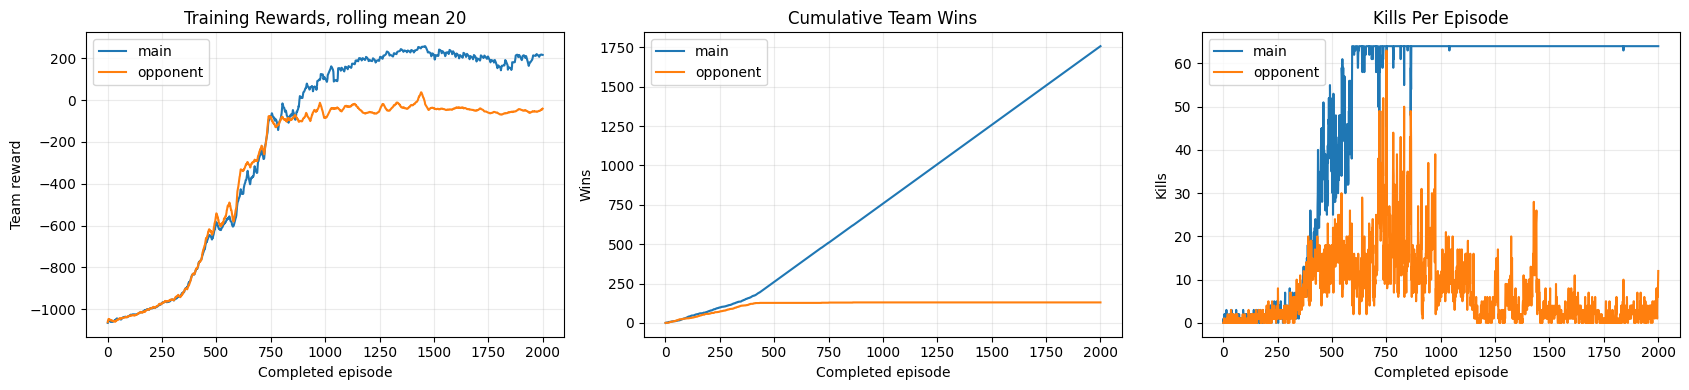

In [10]:
# Robust epsilon schedule: 0.01 -> 0.5
epsilon_start = 0.01
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_01_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_01_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_0_5)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-830.544 mean_opponent_reward=-821.746 loss=0.0136 episodes_per_sec=0.43
[mf_srq_torch] episodes=800/2000 mean_main_reward=-177.340 mean_opponent_reward=-99.215 loss=0.0601 episodes_per_sec=0.31
[mf_srq_torch] episodes=1200/2000 mean_main_reward=187.741 mean_opponent_reward=-34.844 loss=0.2737 episodes_per_sec=0.29
[mf_srq_torch] episodes=1600/2000 mean_main_reward=180.452 mean_opponent_reward=-57.761 loss=0.2045 episodes_per_sec=0.32
[mf_srq_torch] episodes=2000/2000 mean_main_reward=147.216 mean_opponent_reward=-86.326 loss=0.1396 episodes_per_sec=0.33

Training complete. 2000 episodes, 499,687 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_1/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_1/battle_v4/seed42/training_stats.json
Saved tr

{'main': 0.8645, 'opponent': 0.0835}

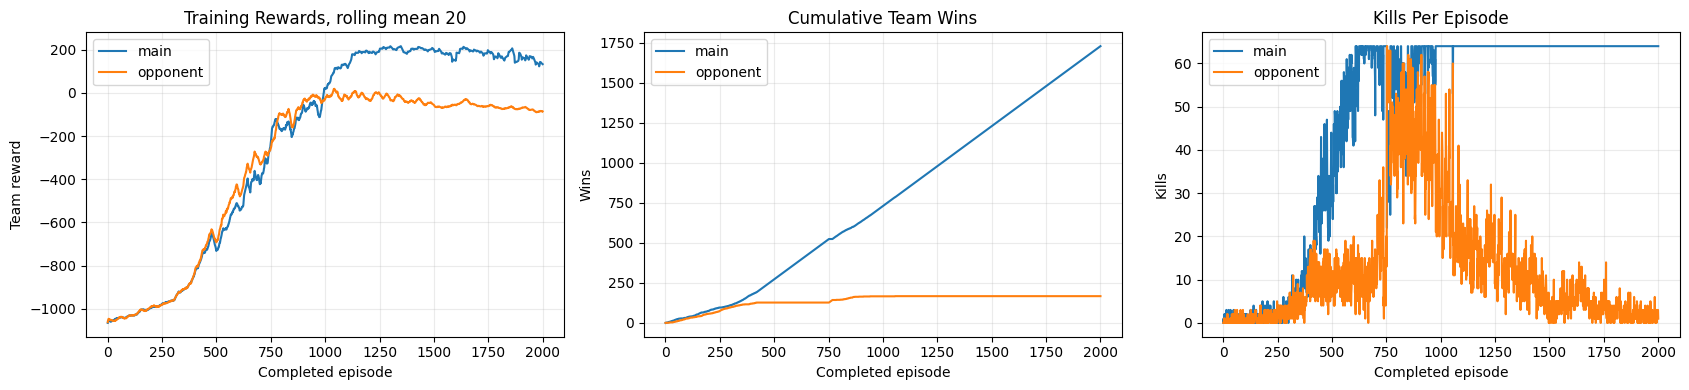

In [11]:
# Robust epsilon schedule: 0.01 -> 1
epsilon_start = 0.01
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_01_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_01_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_1_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-925.319 mean_opponent_reward=-920.588 loss=0.0094 episodes_per_sec=0.42
[mf_srq_torch] episodes=800/2000 mean_main_reward=-244.556 mean_opponent_reward=-234.058 loss=0.0582 episodes_per_sec=0.38
[mf_srq_torch] episodes=1200/2000 mean_main_reward=175.212 mean_opponent_reward=-32.326 loss=0.2820 episodes_per_sec=0.37
[mf_srq_torch] episodes=1600/2000 mean_main_reward=222.590 mean_opponent_reward=-38.103 loss=0.2633 episodes_per_sec=0.41
[mf_srq_torch] episodes=2000/2000 mean_main_reward=203.195 mean_opponent_reward=-33.046 loss=0.1993 episodes_per_sec=0.43

Training complete. 2000 episodes, 525,348 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_1_to_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_1_to_0_5/battle_v4/seed42/training_stats.json
Saved

{'main': 0.8045, 'opponent': 0.1395}

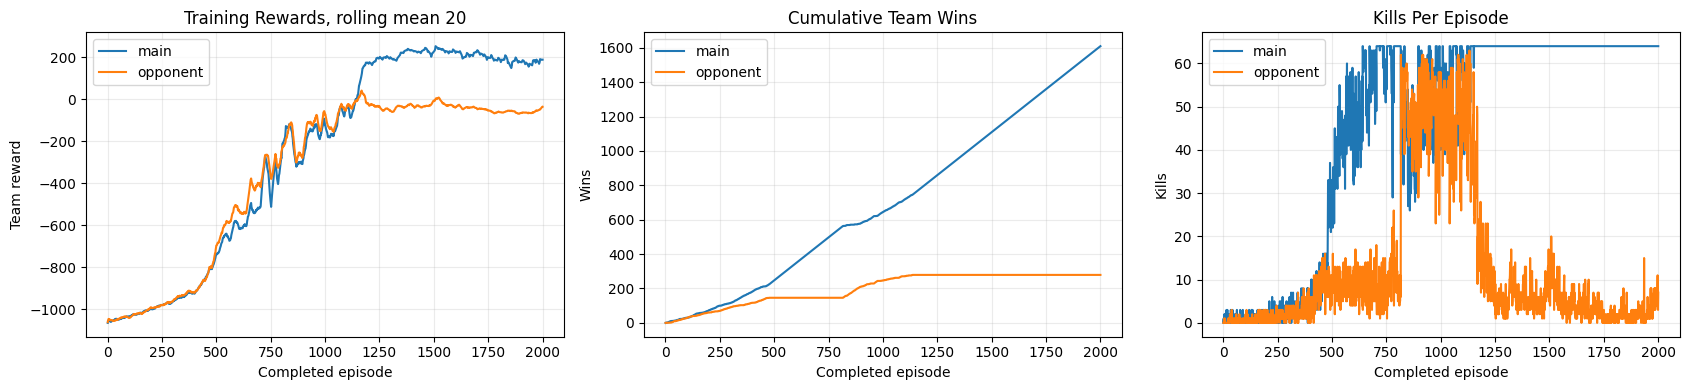

In [12]:
# Robust epsilon schedule: 0.1 -> 0.5
epsilon_start = 0.1
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_1_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_1_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_0_5)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-907.270 mean_opponent_reward=-905.434 loss=0.0080 episodes_per_sec=0.38
[mf_srq_torch] episodes=800/2000 mean_main_reward=-463.632 mean_opponent_reward=-359.342 loss=0.0314 episodes_per_sec=0.32
[mf_srq_torch] episodes=1200/2000 mean_main_reward=58.977 mean_opponent_reward=41.535 loss=0.1705 episodes_per_sec=0.30
[mf_srq_torch] episodes=1600/2000 mean_main_reward=196.236 mean_opponent_reward=-34.130 loss=0.1983 episodes_per_sec=0.32
[mf_srq_torch] episodes=2000/2000 mean_main_reward=160.460 mean_opponent_reward=-47.543 loss=0.1289 episodes_per_sec=0.34

Training complete. 2000 episodes, 547,158 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_1_to_1/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_1_to_1/battle_v4/seed42/training_stats.json
Saved train

{'main': 0.8615, 'opponent': 0.077}

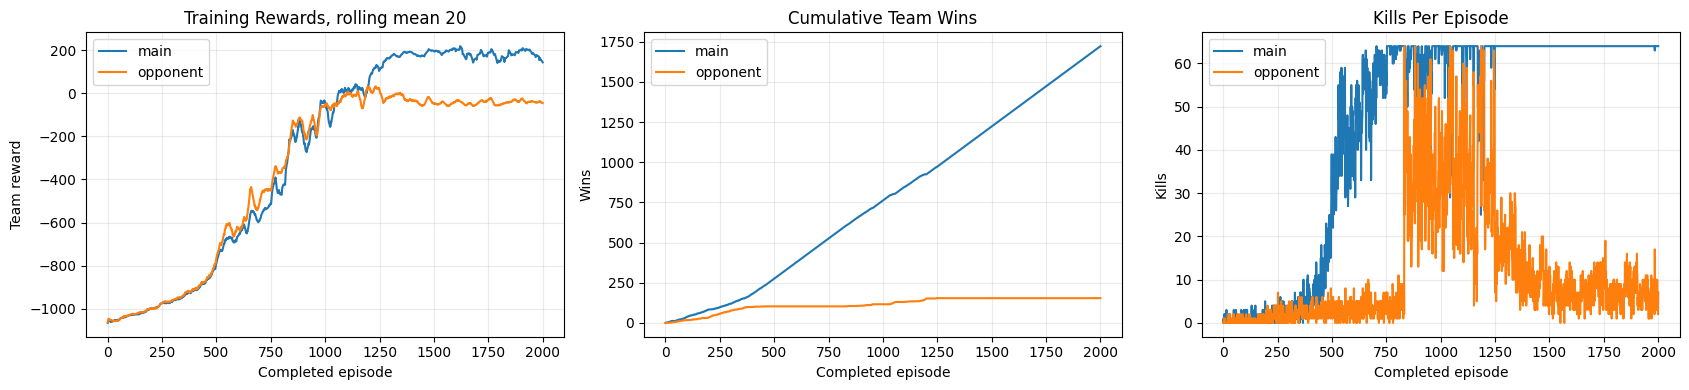

In [13]:
# Robust epsilon schedule: 0.1 -> 1
epsilon_start = 0.1
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_1_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_1_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_1_0)
